Analysis into if cmems is more accurate based off of the initial abbility to predict the the dFADs speeds

- Start by using compairson of CMEMs and the dFADs speeds at current time 
    Produce plot of inital cmems speed errors vs leadtime errors. 
    create a list of all the innital speed errors 


In [1]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
from importlib import reload
import functions.funcs as funcs 
reload(funcs)
import matplotlib.pyplot as plt

In [2]:
ds = gpd.read_parquet(r"Data\Mapped_SAT_MI_Cleanedspeeds.parquet") 
ds = funcs.querry_date_range(ds, pd.Timestamp("2024-1-1"), pd.Timestamp("2025-1-1"))
ds = ds.reset_index(drop = True)
print(ds.columns)
fc = pd.read_csv("Parcels/saved_output/combined_cmems2024.csv")
fc2 = pd.read_csv("Parcels/saved_output/OSCAR_2024v2.csv")
fc3 = pd.read_csv("Parcels/saved_output/No_forecast.csv")
fc["Time"] = pd.to_datetime(fc["Time"])
fc['error_km'] = funcs.haversine_df(fc, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc2["Time"] = pd.to_datetime(fc2["Time"])
fc2["error_km"] = funcs.haversine_df(fc2, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc3["Time"] = pd.to_datetime(fc3["Time"])
fc3["error_km"] = funcs.haversine_df(fc3, "lat_true", "lon_true", "lat_forcast", "lon_forcast")

Index(['index', 'BuoyName', 'MinOfDate', 'MaxOfDate', 'TimeStamp', 'geometry',
       'x_deg', 'y_deg', 'x_km', 'y_km', 'xy_km', 'Delta_Timestamps',
       'x_speed', 'y_speed', 'xy_speed', 'points_removed', 'Masked_array',
       'points_removed2', 'Masked_array2', 'Masked_array_combined', 'mapped_v',
       'mapped_u'],
      dtype='str')


In [4]:
longlist = pd.DataFrame({})
longlist["Time"] = funcs.Column_to_List(ds, "TimeStamp", idlist = False)
longlist["lats"], longlist["lons"] = funcs.list_of_latlon(ds, False)
longlist["x_speed"] = funcs.Column_to_List(ds, "x_speed", idlist = False)
longlist["y_speed"] = funcs.Column_to_List(ds, "y_speed", idlist = False)
longlist["v_mapped"], longlist["BuoyID"]  =funcs.Column_to_List(ds, "mapped_v", idlist = True)
longlist["u_mapped"] = funcs.Column_to_List(ds, "mapped_u", idlist = False)
longlist.Time = pd.to_datetime(longlist.Time)
mask = (longlist.Time > pd.Timestamp('2023-12-31')) 
longlist = longlist[mask].reset_index(drop = True)
longlist = longlist[longlist.Time < pd.Timestamp('2025-1-1')].reset_index(drop = True)

In [74]:
## maps the True dFAD dFADs speeds onto 
merged = pd.merge_asof(
    fc.sort_values('Time'),
    longlist.sort_values('Time'),
    on='Time',
    by='BuoyID',
    tolerance=pd.Timedelta(minutes=1),
    direction='nearest'
)
merged["speed"] = np.sqrt(merged.x_speed**2 + merged.y_speed**2)
merged["starttime"] = (merged.Time - pd.to_timedelta(merged.leadtime, "hours")).dt.round('min')
merged = merged.sort_values('Time')
merged["initial_speed"] = merged.groupby(by=["BuoyID", "starttime"])['speed'].transform('first')
## plot for just 24 hours 
bins = np.linspace(0,8*24,2*24+1)
merged["lead_bins"] = pd.cut(merged["leadtime"], bins)
binlist = merged["lead_bins"].unique()
a  =binlist[7] ## list of bin intervals 
print(a)
mergedhr = merged.groupby("lead_bins").get_group(a)
##now group by speeds and take a mean.
speedbins = np.linspace(0,mergedhr.initial_speed.max(),25 )
mergedhr["speed_bin"] = pd.cut(mergedhr["initial_speed"], speedbins)
binned_errors = mergedhr.groupby("speed_bin")["error_km"].mean()

(24.0, 28.0]


### Speed Corrilations with errors.

In [ ]:
def inital_speed_binning(merged: pd.DataFrame, binindex : int):
    bins = np.linspace(0,8*24,2*24+1)
    merged["lead_bins"] = pd.cut(merged["leadtime"], bins)
    binlist = merged["lead_bins"].unique()
    a  =binlist[binindex] ## list of bin intervals 
    print(a)
    mergedhr = merged.groupby("lead_bins").get_group(a)
    ##now group by speeds and take a mean.
    speedbins = np.linspace(0,mergedhr.initial_speed.max(),25)
    mergedhr["speed_bin"] = pd.cut(mergedhr["initial_speed"], speedbins)
    binned_errors = mergedhr.groupby("speed_bin")["error_km"].mean()
    return speedbins, binned_errors

speedbins, binned_errors = inital_speed_binning(merged,8)

(28.0, 32.0]


(0.0, 4.0]
(4.0, 8.0]
(8.0, 12.0]
(12.0, 16.0]
(16.0, 20.0]
(20.0, 24.0]
(24.0, 28.0]
(28.0, 32.0]
(32.0, 36.0]
(36.0, 40.0]


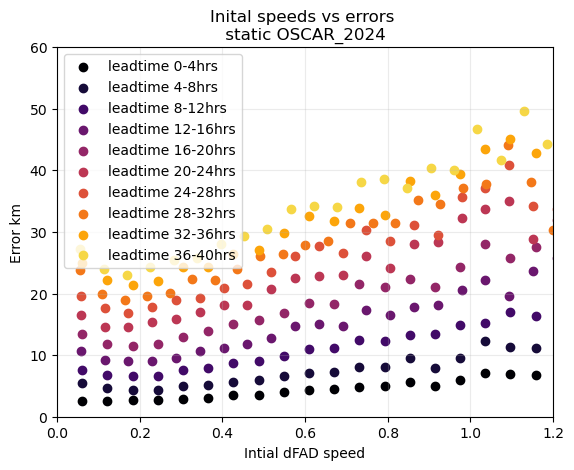

In [7]:
fig, ax = plt.subplots()
cmap = plt.cm.inferno
for i in range(10):
    speedbins, binned_errors = inital_speed_binning(merged,i+1)
    ax.scatter(speedbins[1:], binned_errors, label=f"leadtime {i*4}-{(i+1)*4}hrs", color=cmap(i/10))
ax.set_ylabel("Error km")
ax.set_xlabel("Intial dFAD speed")
ax.set_xlim(0,1.2)
ax.set_ylim(0,60)
ax.set_title("Inital speeds vs errors \n static OSCAR_2024 ")
ax.grid(alpha = 0.25)
ax.legend()

### Projection of dFAD onto the model speeds vs errors. 


In [114]:
merged["projection"] = (merged.y_speed * merged.v_mapped)+ (merged.x_speed * merged.u_mapped)
merged["projection"]  = merged["projection"]/(merged.x_speed**2 +merged.y_speed**2 )**(1/2)
merged["Initial_angle"] = merged["projection"]/(merged.u_mapped**2 +merged.v_mapped**2 )**(1/2)
merged["Initial_angle"] = np.arccos(merged["Initial_angle"])*180/np.pi

def Projection_binning(merged: pd.DataFrame, label:str, binindex : int):
    bins = np.linspace(0,8*24,2*24+1)
    merged["lead_bins"] = pd.cut(merged["leadtime"], bins)
    binlist = merged["lead_bins"].unique()
    a  =binlist[binindex] ## list of bin intervals 
    print(a)
    mergedhr = merged.groupby("lead_bins").get_group(a)
    ##now group by speeds and take a mean.
    speedbins = np.linspace(mergedhr[label].min(),mergedhr[label].max(),25)
    mergedhr["projection_bin"] = pd.cut(mergedhr[label], speedbins)
    binned_errors = mergedhr.groupby("projection_bin")["error_km"].mean()
    return speedbins, binned_errors

speedbins, binned_errors = Projection_binning(merged,"projection", 1)

speedbins[binned_errors.index.codes]


(0.0, 4.0]


array([-0.78453474, -0.62508182, -0.54535537, -0.46562891, -0.38590245,
       -0.30617599, -0.22644953, -0.14672307, -0.06699662,  0.01272984,
        0.0924563 ,  0.17218276,  0.25190922,  0.33163568,  0.41136213,
        0.49108859,  0.57081505,  0.65054151,  0.73026797,  0.80999442,
        0.88972088,  0.96944734])

(24.0, 28.0]
(28.0, 32.0]
(32.0, 36.0]
(36.0, 40.0]
(40.0, 44.0]
(44.0, 48.0]
(48.0, 52.0]
(52.0, 56.0]
(56.0, 60.0]
(60.0, 64.0]


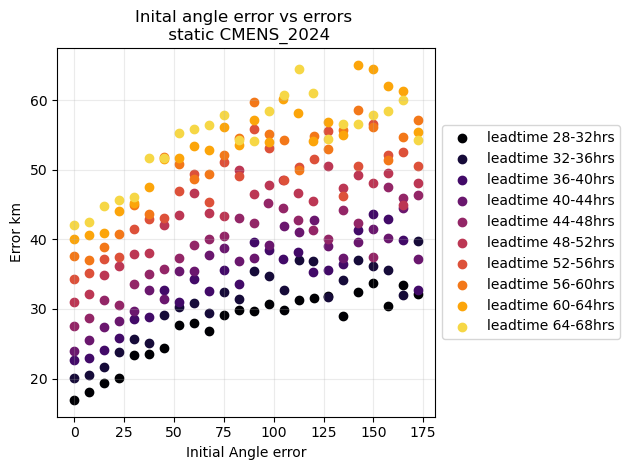

In [115]:
fig, ax = plt.subplots()
cmap = plt.cm.inferno
ofset = 7
timerange = 10
for i in range(timerange):
    speedbins, binned_errors = Projection_binning(merged,"Initial_angle", i+ofset)
    ax.scatter(speedbins[binned_errors.index.codes], binned_errors, label=f"leadtime {(i+ofset)*4}-{(i+ofset+1)*4}hrs", color=cmap(i/timerange))
ax.set_ylabel("Error km")
ax.set_xlabel("Initial Angle error")
#ax.set_xlim(0,1.2)
#ax.set_ylim(0,60)
ax.set_title("Inital angle error vs errors \n static CMENS_2024")
ax.grid(alpha = 0.25)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()

np.float64(0.1481050918391072)

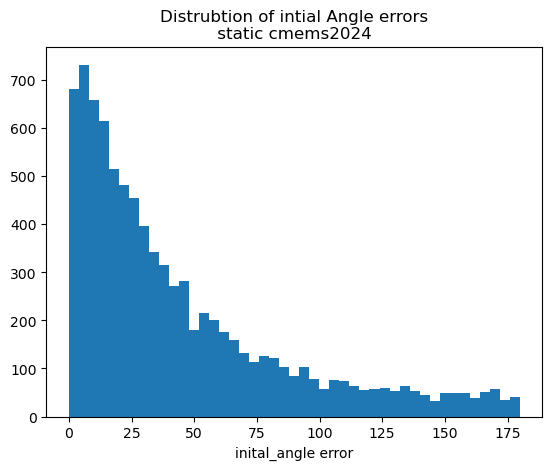

In [125]:
### distribution of inittial error speeds. 
initial_speeds = merged.query("leadtime == 0")
Greater90 = initial_speeds.query("Initial_angle > 90")["Initial_angle"].count()
fig, ax =plt.subplots()
ax.hist(initial_speeds.Initial_angle, 45)
ax.set_xlabel("inital_angle error")
ax.set_title("Distrubtion of intial Angle errors\n static cmems2024 ")
Greater90/initial_speeds.Initial_angle.count()

### Time Series of Errors 

In [131]:
a  = fc["lead_bins"][261107]
def Forecast_timeseries(ds:pd.DataFrame, window:int, bin)-> pd.DataFrame:
    bins = np.linspace(0,8*24,2*24+1)
    ds["lead_bins"] = pd.cut(ds["leadtime"], bins)
    # (24.0, 28.0]
    fc_grouped = ds.groupby("lead_bins")
    fc24 = fc_grouped.get_group(a)
    fc24["Day"] = fc24.Time.dt.date
    ts24 = fc24.groupby("Day")["error_km"].mean()
    ts24 = ts24.to_frame("error_km").reset_index(drop= False)
    ts24["rolling"] = ts24["error_km"].rolling(window).mean()
    return ts24

In [162]:
window = 7
fcts = Forecast_timeseries(fc, window , a)
fcts2 = Forecast_timeseries(fc2,window, a)
fcts3 = Forecast_timeseries(fc3, window, a)

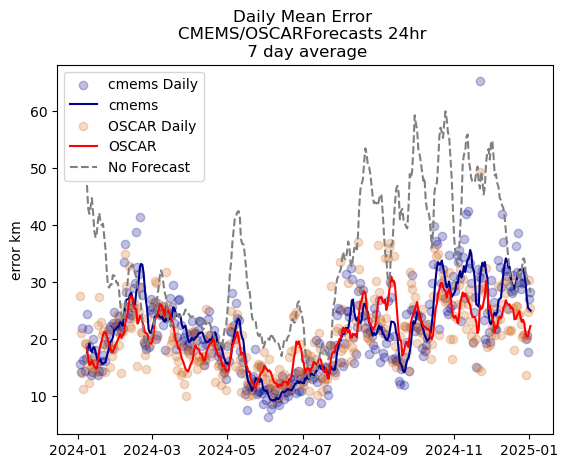

In [169]:
fig, ax = plt.subplots()
#CMEMS
ax.scatter(fcts.Day, fcts.error_km, color = "darkblue", alpha = 0.25, label = "cmems Daily")
ax.plot(fcts.Day, fcts["rolling"], color = "darkblue", label = "cmems")
#OSCAR 
ax.scatter(fcts2.Day, fcts2.error_km, color = "chocolate", alpha = 0.25 ,label = "OSCAR Daily")
ax.plot(fcts2.Day, fcts2["rolling"], color = "red", label = "OSCAR")
#NO Forecast
#ax.scatter(fcts3.Day, fcts3.error_km, color = "g", alpha = 0.25 ,label = "OSCAR Daily")
ax.plot(fcts3.Day, fcts3["rolling"], color = "gray", label = "No Forecast", linestyle = "--")
ax.set_title("Daily Mean Error \nCMEMS/OSCARForecasts 24hr \n 7 day average")
ax.set_ylabel("error km")
ax.legend()